In [ ]:
%pwd
%load_ext autoreload
%autoreload 2

In [14]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from experiments.scripts.run_experiments import run_experiment
from experiments.scripts.experiment_utils import generate_experiments

In [15]:
base_config = {
    # Experiment
    "experiment": "ae_wiggling_tube_w20_b64",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "wiggling_tube",
    "batch_size": 64,
    "deformation_amp": 0.0001,
    "n_phi": 300,
    "n_theta": 30,
    "minor_radius": 0.6,
    "wiggling_dim": 5,
    "embedding_dim": 10,
    "noise_var": 0.0001,
    "rotation": "random",

    # Model
    'model_type': 'EuclideanAE',
    'data_dim': 10,
    'latent_dim': 3,
    'activation': 'softplus',
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100, 100, 100],
    'decoder_widths': [100, 100, 100],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 2,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 0,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": True,
    "compute_emp_curv": True,
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "compute_rec_curv": False,
    "n_plot_points": 8000,
    "n_points_emp_curv": 8000,  # number of points to compute the empirical curvature
    "n_points_pullback_curv": 1500,  # number of points to compute the pullback (true/learned). Should be 1000-2000.
    "k": 500,
    "smoothing": False,
    # heuristics (estimation_points, k)
    #   n_phi=200, n_theta=20, minor_radius = 0.5: (5000, 100)
    #   n_phi=300, n_theta=30, minor_radius = 0.6: (8000,500)


    # Persistent homology
    "persistent_homology": True,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1, 2]
}

param_grid = {
    "alpha": [1] * 3 + [1, 1, 1, 0] * 3,
    "gamma": [0] * 3 + [1, 100, 1000, 1] * 3,
    "dim_topo_loss": [0,1,2] + [0] * 4 + [1] * 4 + [2] * 4,
}

all_configs = generate_experiments(base_config, param_grid)


Running exp00_ae_wiggling_tube_w20_b64. 
Description: alpha=1, gamma=0, dim_topo_loss=0
--------------------------------------------------------------------------------------


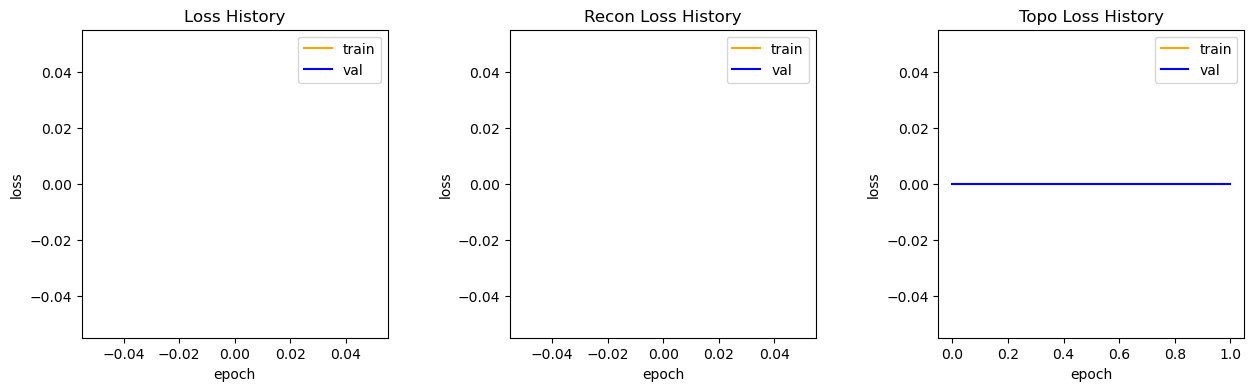

NaNs detected in the dataset!


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

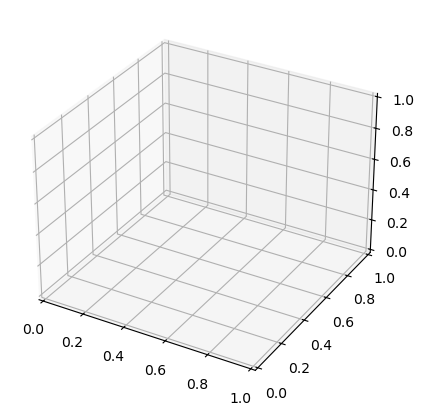

In [16]:
run_experiment(all_configs=all_configs)